In [1]:
from typing import Any, Optional
from arcengine import GameAction


from arcengine import FrameDataRaw

from arc import MyArcSession
from arc_agi import OperationMode
from arc_agi import Arcade
import logging
import numpy as np
from dotenv import load_dotenv
from PIL import Image
from sandbox import SandboxOrchestrator
from google.genai import types
from google import genai
from tools import TOOL_LIST, SYSTEM_PROMPT, TAKE_ACTION
from agent import JackAgent
import io

load_dotenv()


PALETTE = np.array(
    [
        [0xFF, 0xFF, 0xFF],
        [0xCC, 0xCC, 0xCC],
        [0x99, 0x99, 0x99],
        [0x66, 0x66, 0x66],
        [0x33, 0x33, 0x33],
        [0x00, 0x00, 0x00],
        [0xE5, 0x3A, 0xA3],
        [0xFF, 0x7B, 0xCC],
        [0xF9, 0x3C, 0x31],
        [0x1E, 0x93, 0xFF],
        [0x88, 0xD8, 0xF1],
        [0xFF, 0xDC, 0x00],
        [0xFF, 0x85, 0x1B],
        [0x92, 0x12, 0x31],
        [0x4F, 0xCC, 0x30],
        [0xA3, 0x56, 0xD6],
    ],
    dtype=np.uint8,
)


def render_frame(frame: np.ndarray) -> Image.Image:
    rgb = PALETTE[np.clip(np.asarray(frame, dtype=np.uint8), 0, 15)]
    return Image.fromarray(rgb).resize((512, 512), Image.NEAREST)


logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%H:%M:%S"
)


def current_state_prompt(obs: FrameDataRaw) -> str:
    return f"""Currently playing game: {obs.game_id}. On level #{obs.levels_completed} out of #{obs.win_levels}.

"""


def starting_state_prompt(obs: FrameDataRaw) -> str:
    res = f"""Starting the following game: {obs.game_id}

"""

    return (
        f"New game started. Initial state:\n{json.dumps(obs, indent=2)}\n\n"
        f"The full grid is in /home/agent/state.json. "
        f"Start by calling render_board to see the board, then take actions to explore."
    )

In [2]:

arcade = Arcade(operation_mode=OperationMode("normal"))
scorecard_id: str = arcade.open_scorecard(tags=["jackagent"])
arc_session = MyArcSession(
    game_id=["ls20", "ft09", "vc33"][0], arcade=arcade, scorecard_id=scorecard_id
)
sbx = SandboxOrchestrator()
print(sbx.bash("echo sandbox ready"))

agent = JackAgent(sbx=sbx, arc_session=arc_session)


agent.contents = []

2026-04-13 04:25:14 | INFO | Successfully fetched 25 environment(s) from API


04:25:14 Successfully fetched 25 environment(s) from API


2026-04-13 04:25:14 | INFO | Created new scorecard: 1c7b3f08-8d0b-41f0-a569-c06091fd5a4f


04:25:14 Created new scorecard: 1c7b3f08-8d0b-41f0-a569-c06091fd5a4f


2026-04-13 04:25:14 | INFO | Successfully fetched metadata for game ls20


...

2026-04-13 04:25:14 | INFO | Recording to recordings/1c7b3f08-8d0b-41f0-a569-c06091fd5a4f/ls20-9607627b-a4cba94b-e776-4bcb-9598-ac74da959833.jsonl


04:25:14 Recording to recordings/1c7b3f08-8d0b-41f0-a569-c06091fd5a4f/ls20-9607627b-a4cba94b-e776-4bcb-9598-ac74da959833.jsonl


2026-04-13 04:25:14 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


04:25:14 Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


sandbox ready


04:25:24 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; render_board()"'}
  → no output



04:25:26 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



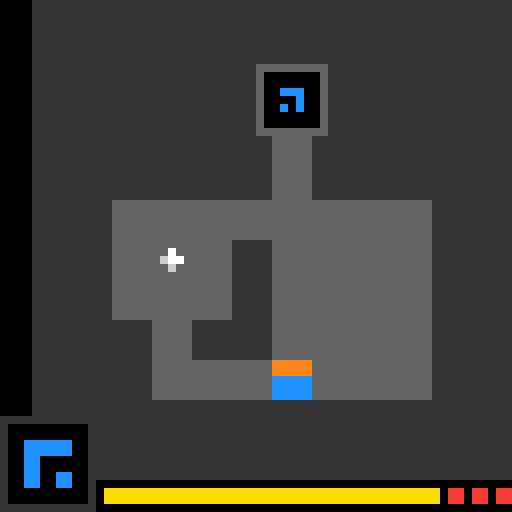

04:25:32 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; print(color_counts(load_grid()))"'}
  → {5: 439, 4: 2609, 3: 892, 9: 45, 0: 3, 1: 2, 12: 10, 11: 84, 8: 12}



04:25:36 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > analyze.py\nfrom helpers import *\nimport numpy as np\n\ngrid = load_grid()\n\ndef bounding_box(c):\n    positions = find_color(grid, c)\n    if not positions:\n        return None\n    rs, cs = zip(*positions)\n    return min(rs), max(rs), min(cs), max(cs)\n\nfor c in sorted(np.unique(grid)):\n    bb = bounding_box(c)\n    print(f"Color {c}: count={np.sum(grid == c)}, bbox={bb}")\n\nEOF\npython3 analyze.py'}
  → Color 0: count=3, bbox=(31, 32, 21, 22)
Color 1: count=2, bbox=(32, 33, 20, 21)
Color 3: count=892, bbox=(8, 49, 14, 53)
Color 4: count=2609, bbox=(0, 63, 0, 63)
Color 5: count=439, bbox=(0, 63, 0, 63)
Color 8: count=12, bbox=(61, 62, 56, 63)
Color 9: count=45, bbox=(11, 60, 3, 38)
Color 11: count=8



04:25:43 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



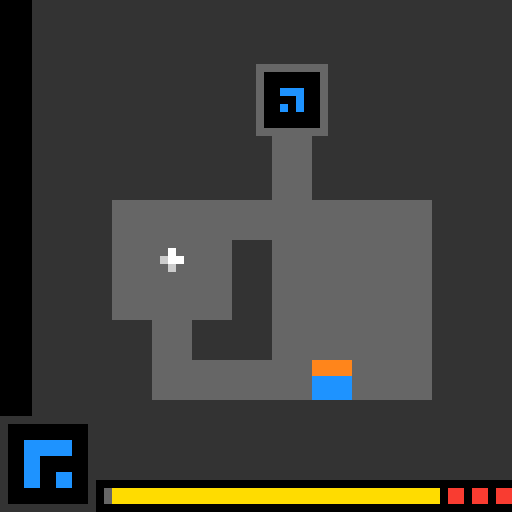

04:25:46 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "\nfrom helpers import *\nimport numpy as np\nold_grid = load_grid()\n# Oh, we don\'t have the old grid, wait. Replay history has grid? No, replay history has no grid.\n"'}
  → no output



04:25:49 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; render_board()"'}
  → no output



04:25:51 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



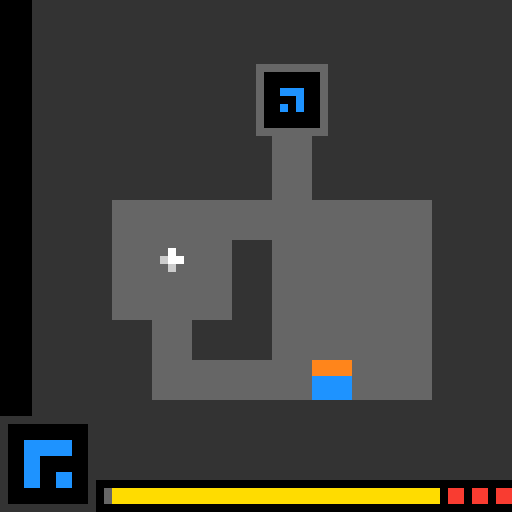

04:25:56 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 analyze.py'}
  → Color 0: count=3, bbox=(31, 32, 21, 22)
Color 1: count=2, bbox=(32, 33, 20, 21)
Color 3: count=894, bbox=(8, 62, 13, 53)
Color 4: count=2609, bbox=(0, 63, 0, 63)
Color 5: count=439, bbox=(0, 63, 0, 63)
Color 8: count=12, bbox=(61, 62, 56, 63)
Color 9: count=45, bbox=(11, 60, 3, 43)
Color 11: count=8



04:26:03 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



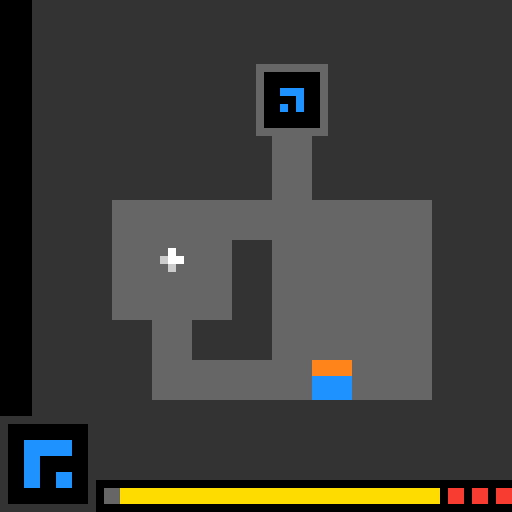

04:26:05 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 analyze.py'}
  → Color 0: count=3, bbox=(31, 32, 21, 22)
Color 1: count=2, bbox=(32, 33, 20, 21)
Color 3: count=896, bbox=(8, 62, 13, 53)
Color 4: count=2609, bbox=(0, 63, 0, 63)
Color 5: count=439, bbox=(0, 63, 0, 63)
Color 8: count=12, bbox=(61, 62, 56, 63)
Color 9: count=45, bbox=(11, 60, 3, 43)
Color 11: count=8



04:26:10 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



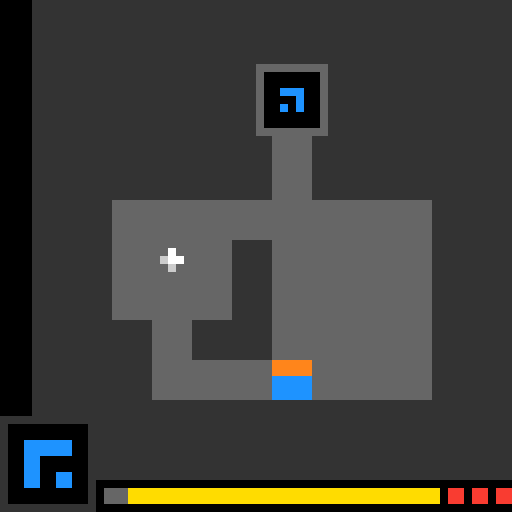

04:26:13 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 analyze.py'}
  → Color 0: count=3, bbox=(31, 32, 21, 22)
Color 1: count=2, bbox=(32, 33, 20, 21)
Color 3: count=898, bbox=(8, 62, 13, 53)
Color 4: count=2609, bbox=(0, 63, 0, 63)
Color 5: count=439, bbox=(0, 63, 0, 63)
Color 8: count=12, bbox=(61, 62, 56, 63)
Color 9: count=45, bbox=(11, 60, 3, 38)
Color 11: count=7



04:26:18 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > diff.py\nfrom helpers import *\nimport numpy as np\nimport sys\nimport json\n\nwith open(\'/home/agent/replay.jsonl\', \'r\') as f:\n    lines = f.readlines()\n    \n# We want to see what actions correspond to what changes. Let\'s just look at the board image to understand.\nEOF\npython3 -c "from helpers import *; render_board()"\n'}
  → no output



04:26:20 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



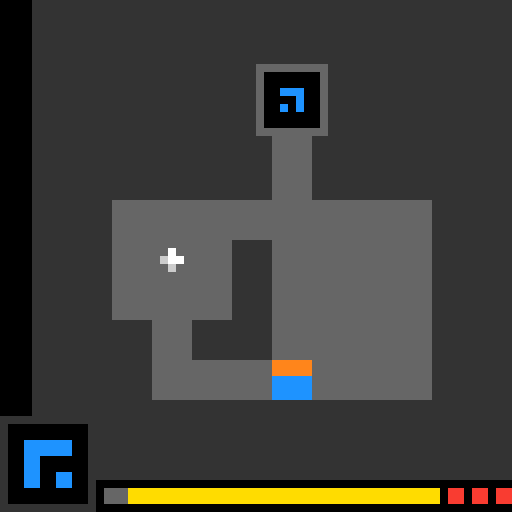

04:26:28 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



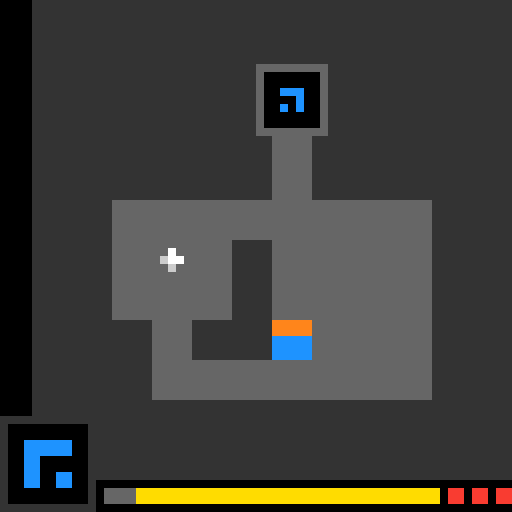

04:26:30 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 analyze.py'}
  → Color 0: count=3, bbox=(31, 32, 21, 22)
Color 1: count=2, bbox=(32, 33, 20, 21)
Color 3: count=900, bbox=(8, 62, 13, 53)
Color 4: count=2609, bbox=(0, 63, 0, 63)
Color 5: count=439, bbox=(0, 63, 0, 63)
Color 8: count=12, bbox=(61, 62, 56, 63)
Color 9: count=45, bbox=(11, 60, 3, 38)
Color 11: count=7



04:26:35 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; render_board()"'}
  → no output



04:26:38 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



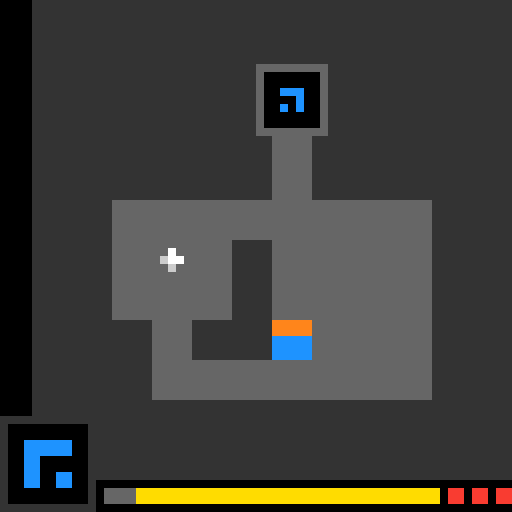

04:26:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



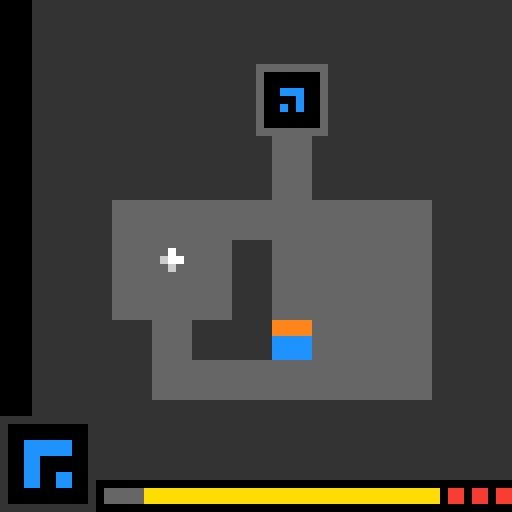

04:26:50 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



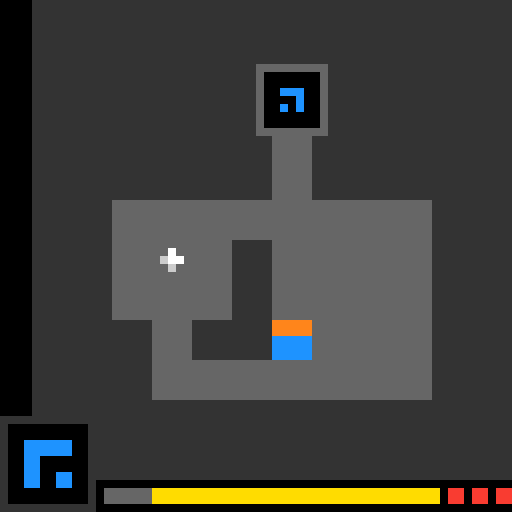

04:26:53 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



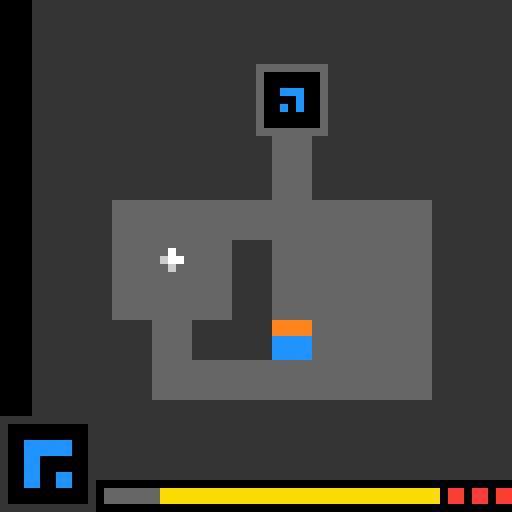

04:26:56 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 analyze.py'}
  → Color 0: count=3, bbox=(31, 32, 21, 22)
Color 1: count=2, bbox=(32, 33, 20, 21)
Color 3: count=906, bbox=(8, 62, 13, 53)
Color 4: count=2609, bbox=(0, 63, 0, 63)
Color 5: count=439, bbox=(0, 63, 0, 63)
Color 8: count=12, bbox=(61, 62, 56, 63)
Color 9: count=45, bbox=(11, 60, 3, 38)
Color 11: count=7



04:26:59 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; render_board()"'}
  → no output



04:27:02 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



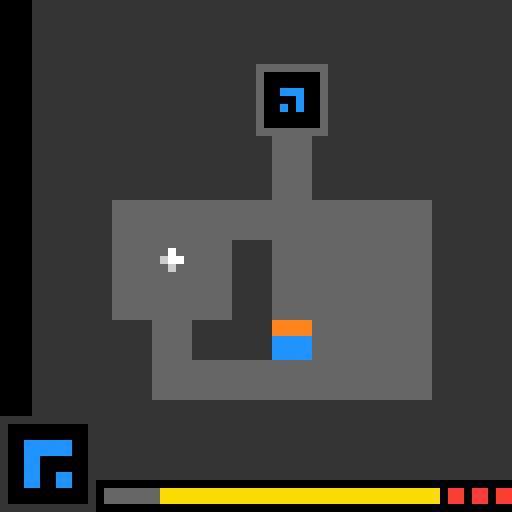

04:27:06 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



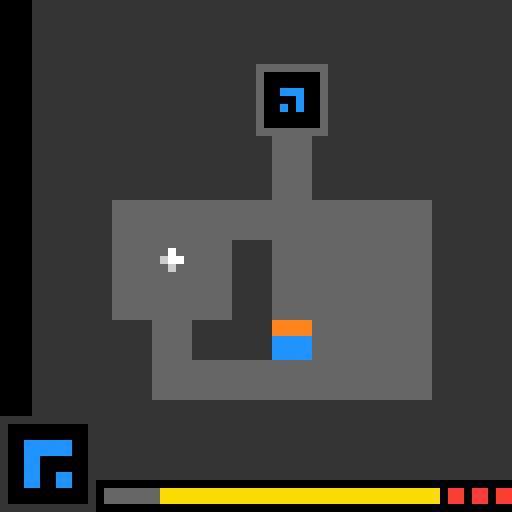

04:27:13 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > tracker.py\nfrom helpers import *\nimport numpy as np\n\ndef print_board_text():\n    grid = load_grid()\n    # just print unique symbols for blocks\n    # 3: \' \', 4: \'#\', 9: \'B\', 12: \'O\', 0: \'*\', 1: \'*\'\n    for r in range(0, 64, 5):\n        row_str = ""\n        for c in range(0, 64, 5):\n            val = grid[r, c]\n            if val == 4: row_str += "█"\n            elif val == 3: row_str += "."\n            elif val == 9: row_str += "B"\n            elif val == 12: row_str += "O"\n            elif val == 0 or val == 1: row_str += "*"\n            else: row_str += str(val)\n        print(row_str)\n\nprint_board_text()\nEOF\npython3 tracker.py'}
  → 5████████████
5████████████
5██████5.████
5██████5.████
5██████.█████
5██........██
5██...█....██
5██...█....██
5███.██O...██
5███.......██
5████████████
█B5██████████
█555555555555



04:27:20 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > tracker.py\nfrom helpers import *\nimport numpy as np\n\ndef print_board_text():\n    grid = load_grid()\n    for r in range(0, 60, 5):\n        row_str = ""\n        for c in range(0, 60, 5):\n            val = grid[r+2, c+2]\n            if val == 4: row_str += "█"\n            elif val == 3: row_str += "."\n            elif val == 9: row_str += "B"\n            elif val == 12: row_str += "O"\n            elif val == 0 or val == 1: row_str += "*"\n            elif val == 5: row_str += " "\n            else: row_str += str(val)\n        print(row_str)\n\nprint_board_text()\nEOF\npython3 tracker.py'}
  → ███████████
 ███████████
 █████.B████
 ██████.████
 ██████.████
 ██........█
 ██.*.█....█
 ██...█....█
 ███.██B...█
 ███.......█
████████████
  ██████████



04:27:24 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


...

[bash] {'command': 'cat << \'EOF\' > tracker.py\nfrom helpers import *\nimport numpy as np\n\ndef print_board_text():\n    grid = load_grid()\n    for r in range(0, 60, 5):\n        row_str = ""\n        for c in range(0, 60, 5):\n            val = grid[r+2, c+2]\n            block = grid[r:r+5, c:c+5]\n            if 12 in block:\n                row_str += "C"\n            elif 0 in block or 1 in block:\n                row_str += "*"\n            elif val == 4:\n                row_str += "█"\n            elif val == 3:\n                row_str += "."\n            elif val == 9:\n                row_str += "B"\n            elif val == 5:\n                row_str += " "\n            else:\n                row_str += "?"\n        print(f"{r//5:2d} " + row_str)\n\nprint_board_text()\nEOF\npython3 tracker.py'}
  → 0  ███████████
 1  ███████████
 2  █████.B████
 3  ██████.████
 4  ██████.████
 5  ██........█
 6  ██.*.█....█
 7  ██...█....█
 8  ███.█CC...█
 9  ███.......█
10 ████████████


04:27:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat << \'EOF\' > find_grid.py\nfrom helpers import *\nimport numpy as np\n\ngrid = load_grid()\n# find boundaries of color 3\nrows, cols = np.where(grid == 3)\nprint(f"Floor rows: {min(rows)} to {max(rows)}")\nprint(f"Floor cols: {min(cols)} to {max(cols)}")\n\n# find all top-left corners of 5x5 blocks\n# just print a 64x64 ascii map\nwith open("map.txt", "w") as f:\n    for r in range(64):\n        s = ""\n        for c in range(64):\n            v = grid[r,c]\n            if v == 4: s += "█"\n            elif v == 3: s += "."\n            elif v == 12: s += "C"\n            elif v == 9: s += "b"\n            elif v == 0: s += "*"\n            elif v == 1: s += "+"\n            elif v == 5: s += " "\n            elif v == 11: s += "y"\n            elif v == 8: s += "r"\n            else: s += "?"\n        f.write(s + "\\n")\nEOF\npython3 find_grid.py && cat map.txt'}
  → Floor rows: 8 to 62
Floor cols: 13 to 53
    ██████████████████████████████████████████████████

04:27:54 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



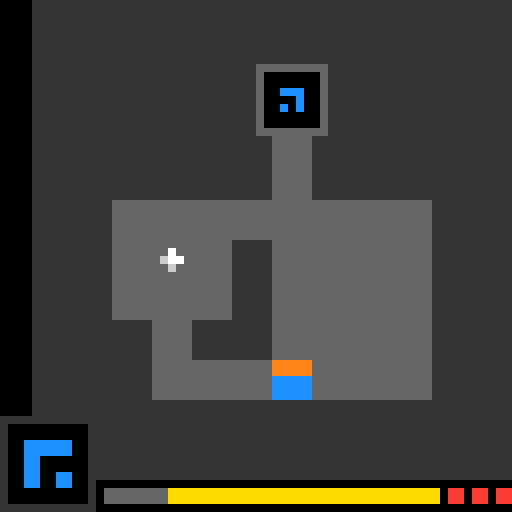

04:27:59 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



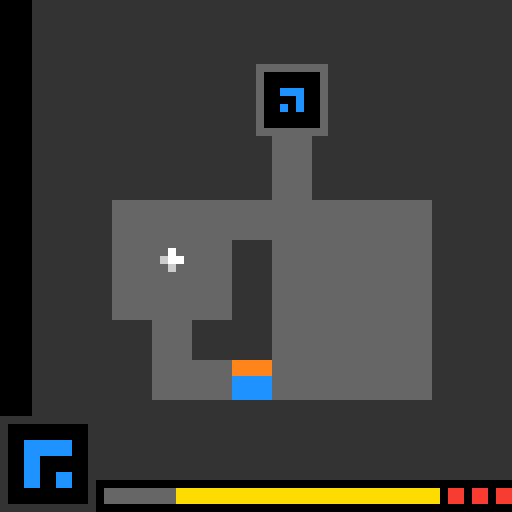

04:28:03 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



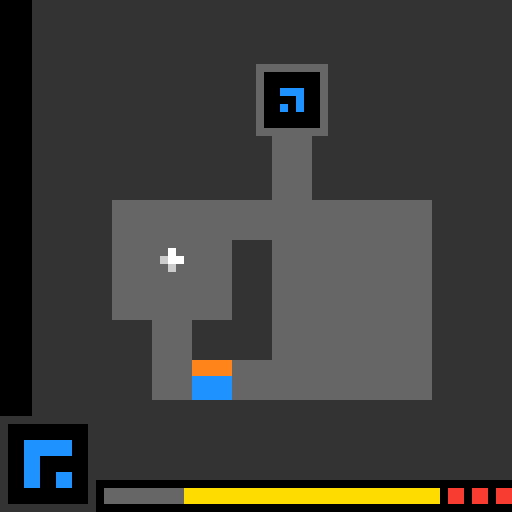

04:28:06 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



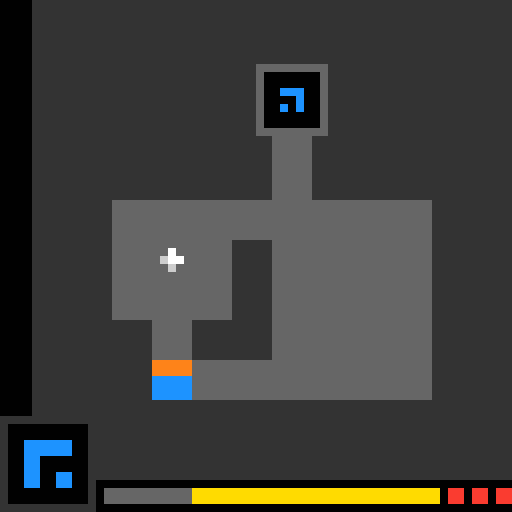

04:28:12 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



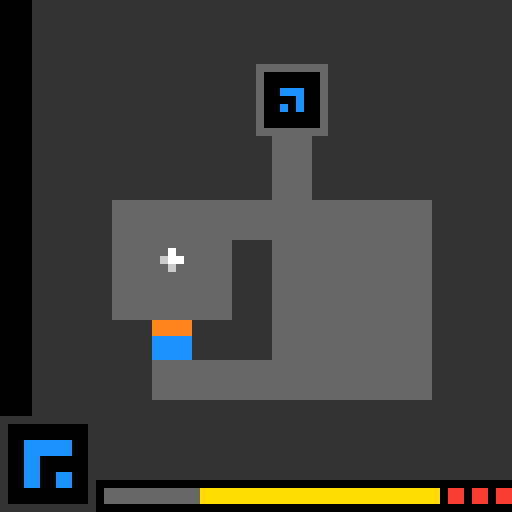

04:28:15 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



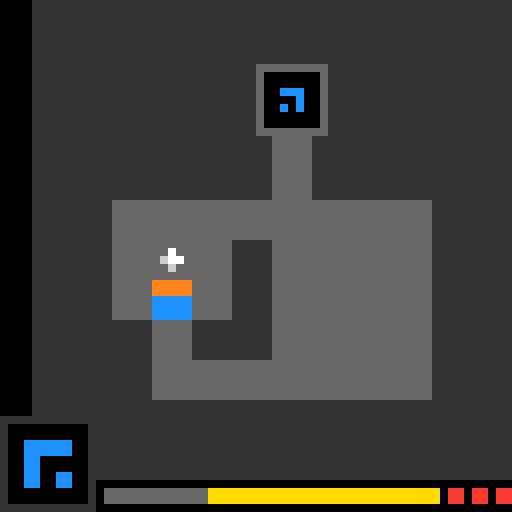

04:28:20 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



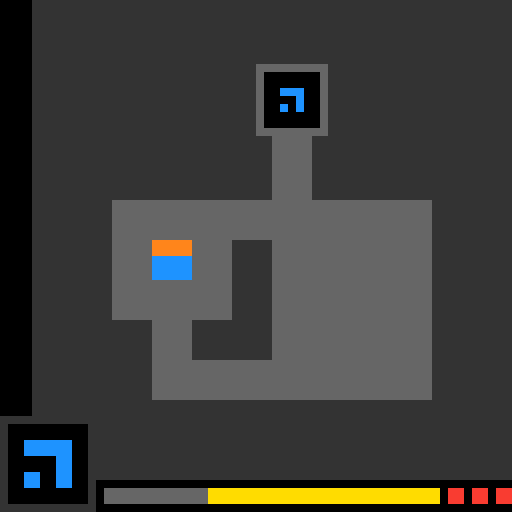

04:28:24 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt'}
  → Floor rows: 8 to 62
Floor cols: 13 to 53
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████



04:28:29 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat /home/agent/state.json | grep score'}
  → Exit code 1



04:28:33 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


...

[bash] {'command': 'python3 -c "from helpers import load_obs; print(load_obs()[\'levels_completed\'])"'}
  → 0



04:28:50 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; render_board()"'}
  → no output



04:28:53 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



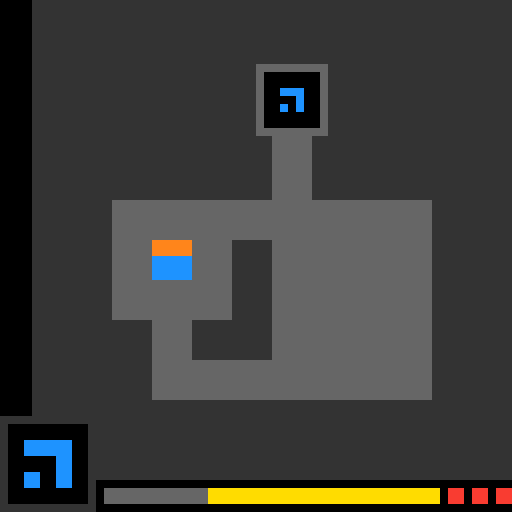

04:29:02 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



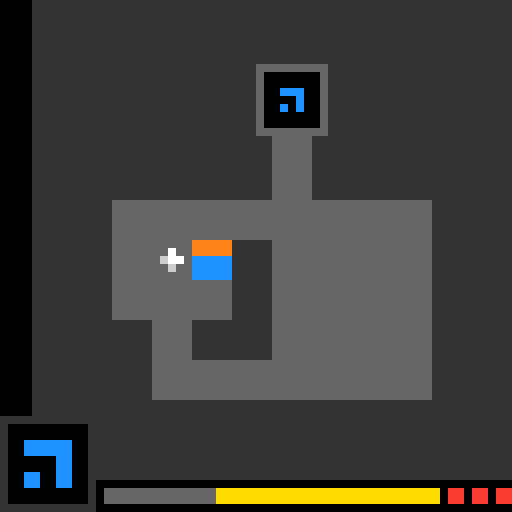

04:29:05 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



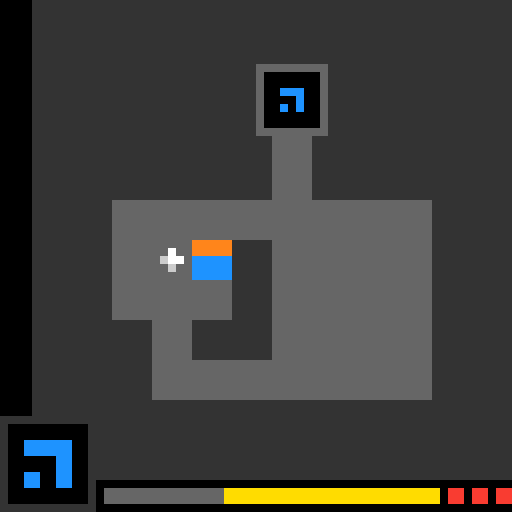

04:29:08 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



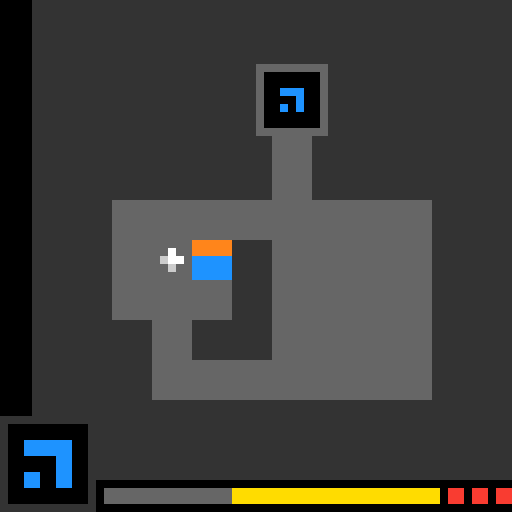

04:29:13 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



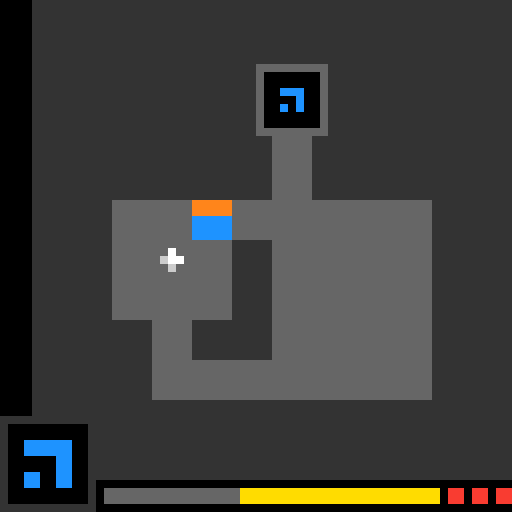

04:29:17 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



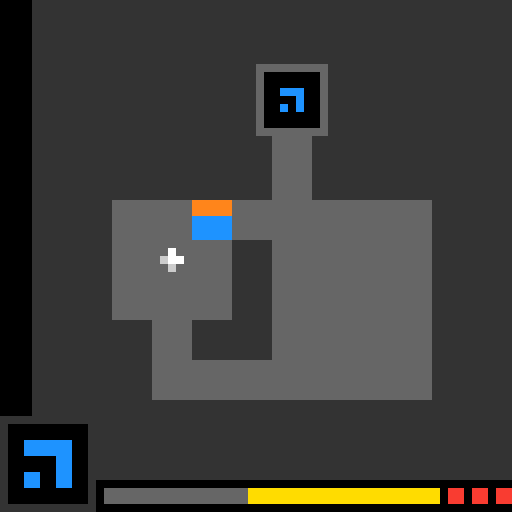

04:29:19 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



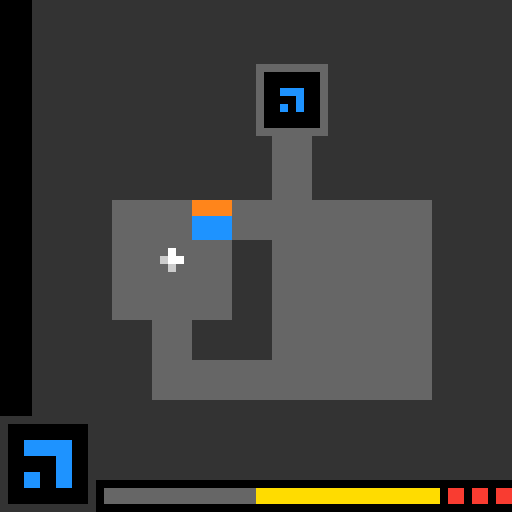

04:29:22 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



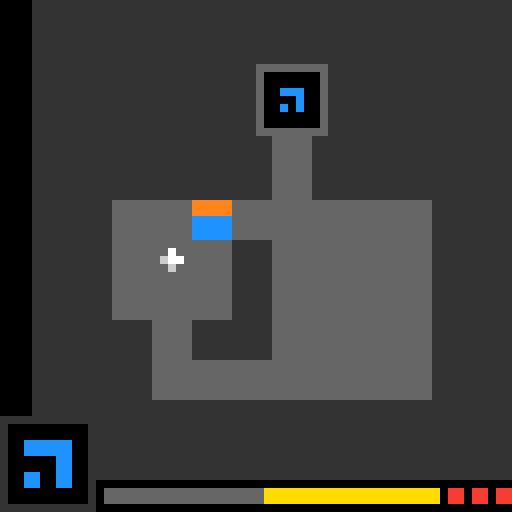

04:29:26 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import load_obs; print(load_obs()[\'levels_completed\'])"'}
  → 0



04:29:29 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt'}
  → Floor rows: 8 to 62
Floor cols: 13 to 53
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████



04:29:36 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'tail -n 10 /home/agent/replay.jsonl'}
  → {"timestamp": "2026-04-13T08:28:12.201635+00:00", "data": {"game_id": "ls20-9607627b", "state": "NOT_FINISHED", "levels_completed": 0, "win_levels": 7, "action_input": {"id": "ACTION1", "data": {}, "reasoning": null}, "guid": "a4cba94b-e776-4bcb-9598-ac74da959833", "full_reset": false, "available_ac



04:29:43 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat map.txt'}
  → ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████



04:29:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



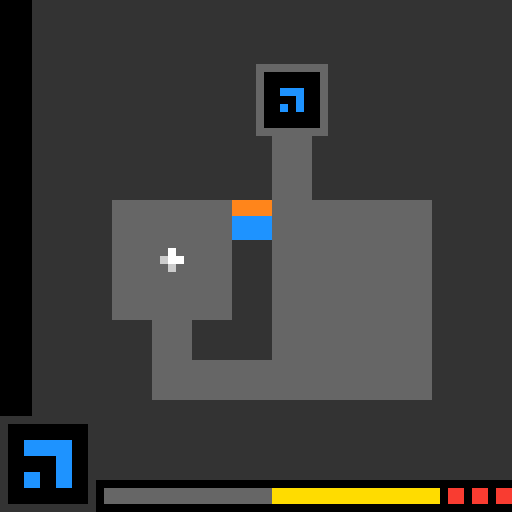

04:29:52 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



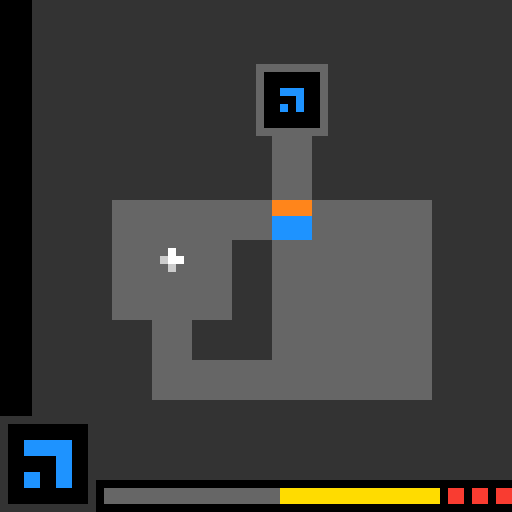

04:29:56 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



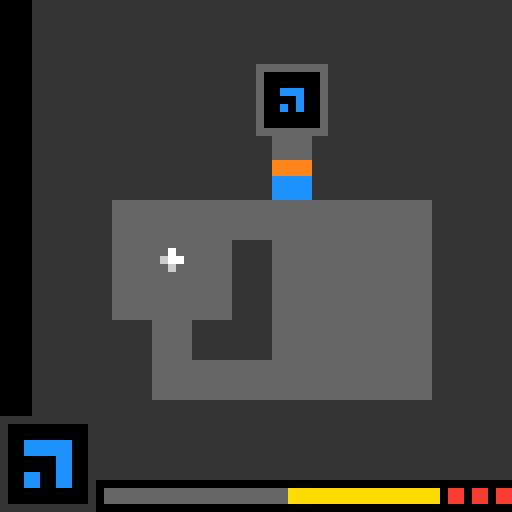

04:30:00 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=0/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



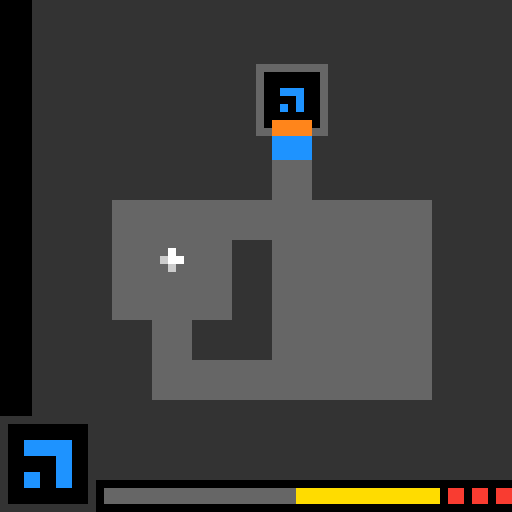

04:30:05 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



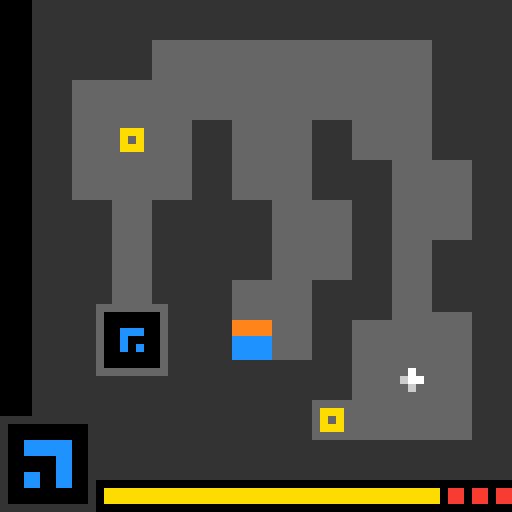

04:30:09 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt'}
  → Floor rows: 5 to 54
Floor cols: 9 to 58
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████




04:30:18 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 -c "from helpers import *; render_board()"'}
  → no output



04:30:23 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[view_image] {'file_path': 'board.png'}
  → Displaying board.png



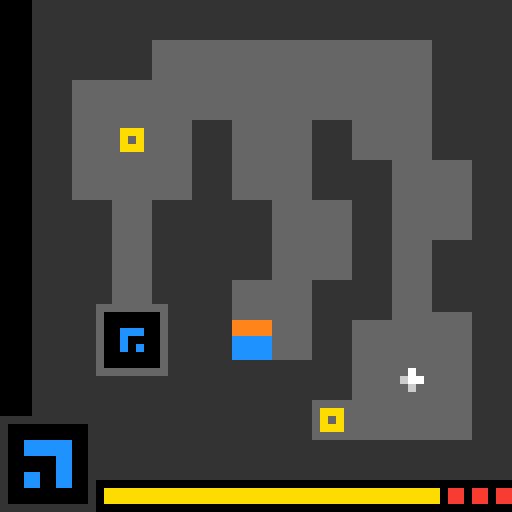

04:30:40 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



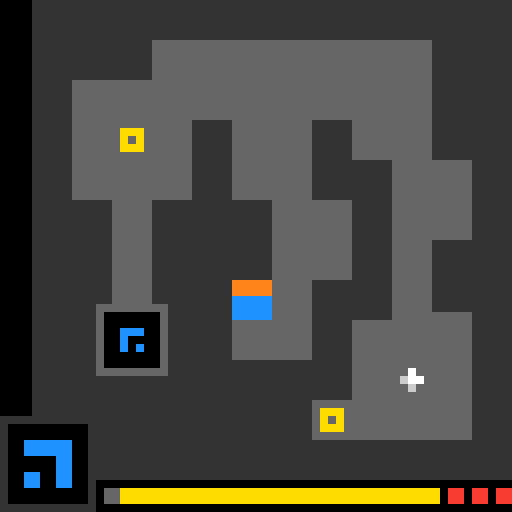

04:30:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



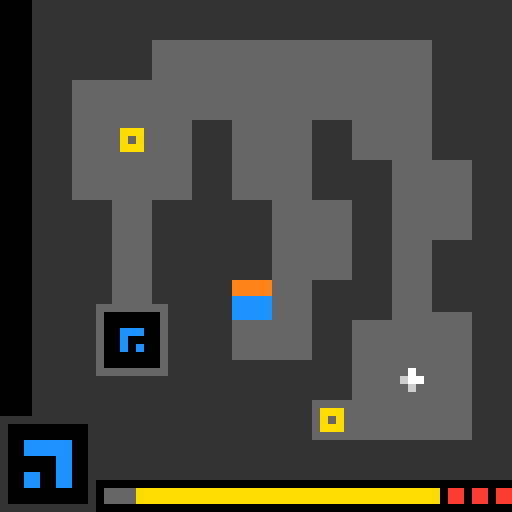

04:30:46 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



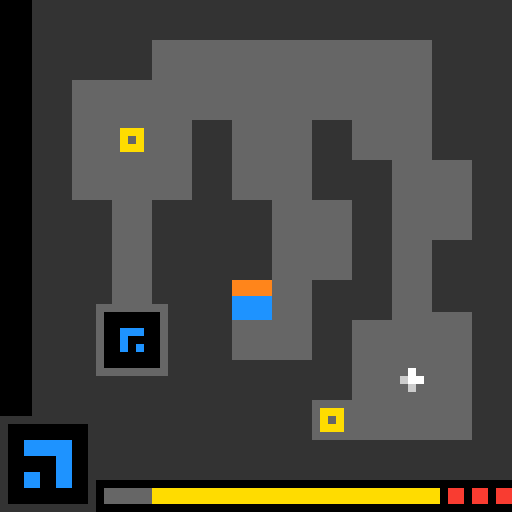

04:30:49 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



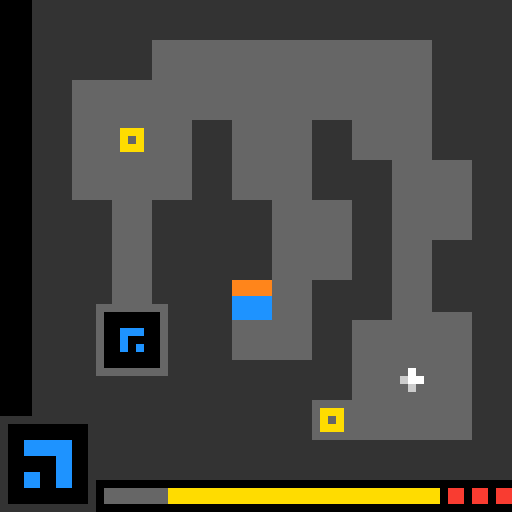

04:30:57 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



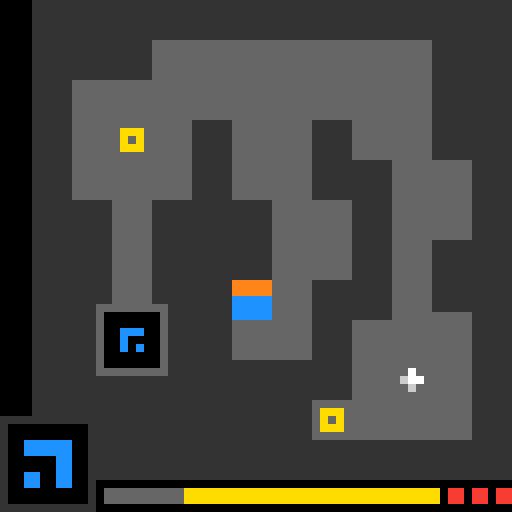

04:31:01 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



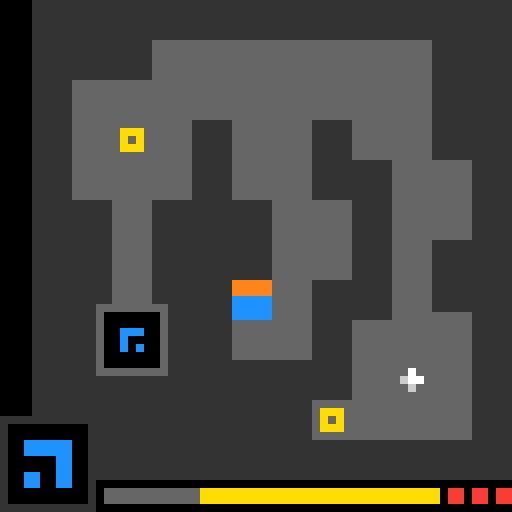

04:31:07 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt | grep -C 5 CCCCC'}
  → Floor rows: 5 to 62
Floor cols: 9 to 58
    ██████████.....███████████████..........█████.....██████████
    ██████████.....███████████████..........█████.....██████████
    ██████████.....███████████████..........█████.....██████████
    ██████████.....███████████████..........█████.....██████████




04:31:15 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



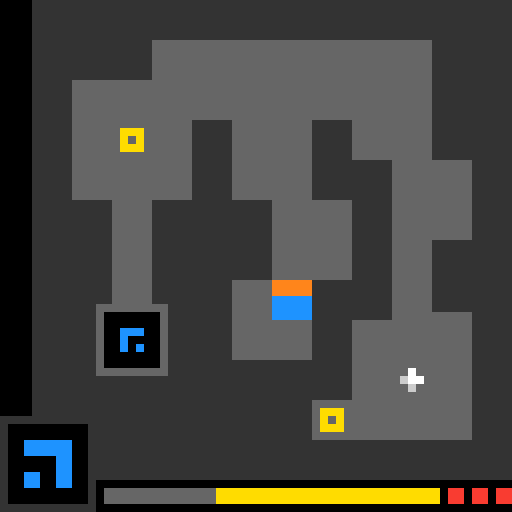

04:31:18 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



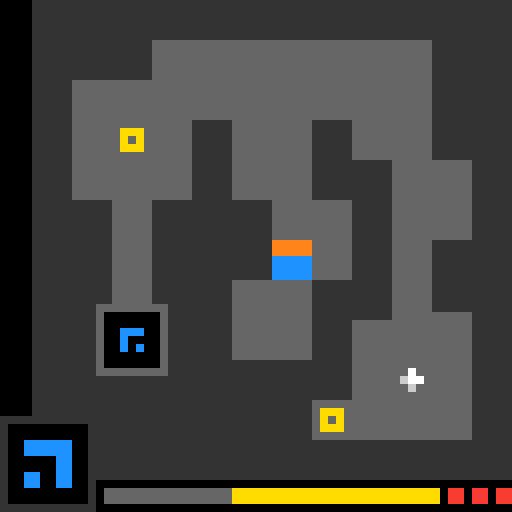

04:31:22 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



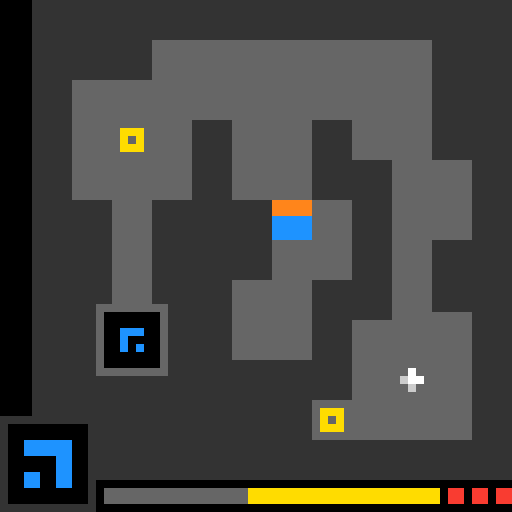

04:31:25 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



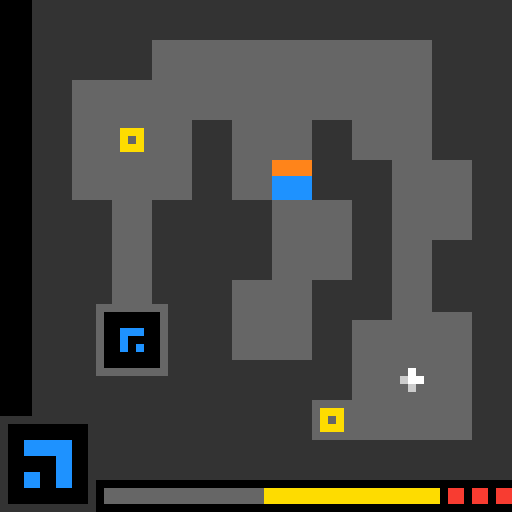

04:31:28 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



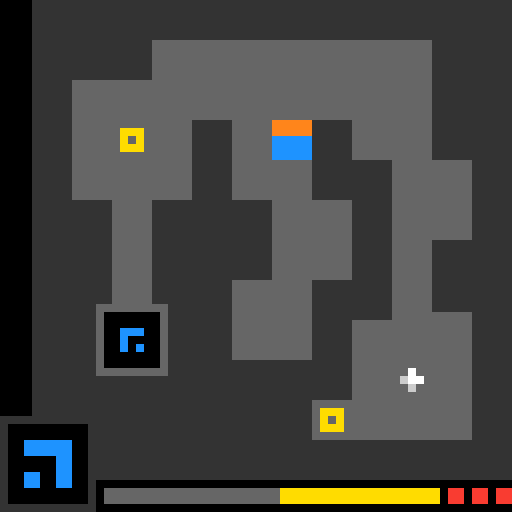

04:31:32 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



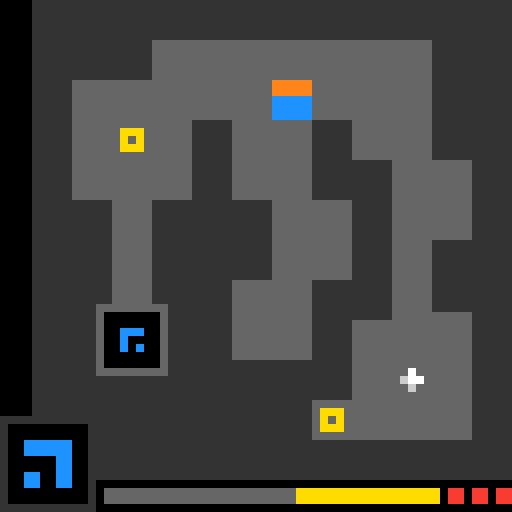

04:31:35 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt | grep -C 5 CCCCC'}
  → Floor rows: 5 to 62
Floor cols: 9 to 58
    ███████████████...................................██████████
    ███████████████...................................██████████
    ███████████████...................................██████████
    ███████████████...................................██████████




04:31:39 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



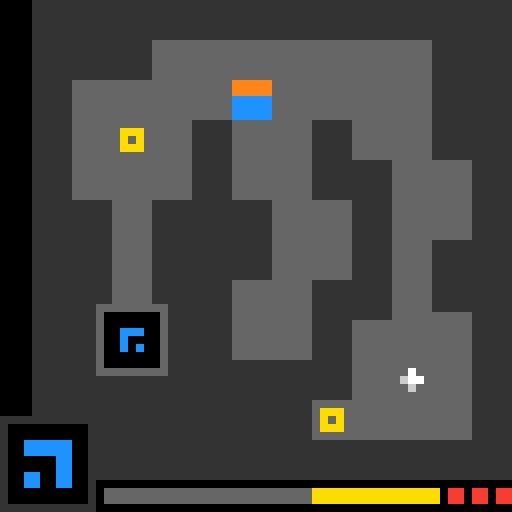

04:31:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



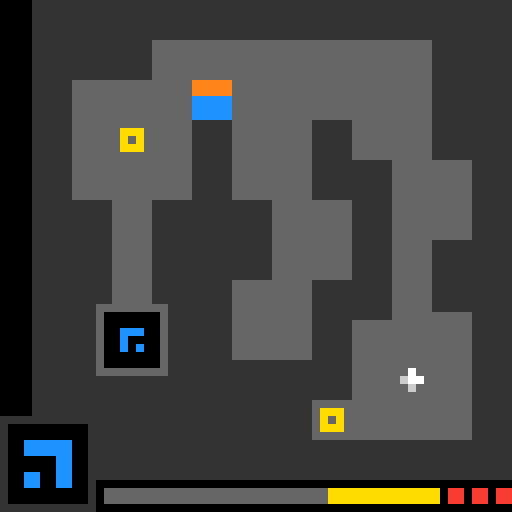

04:31:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



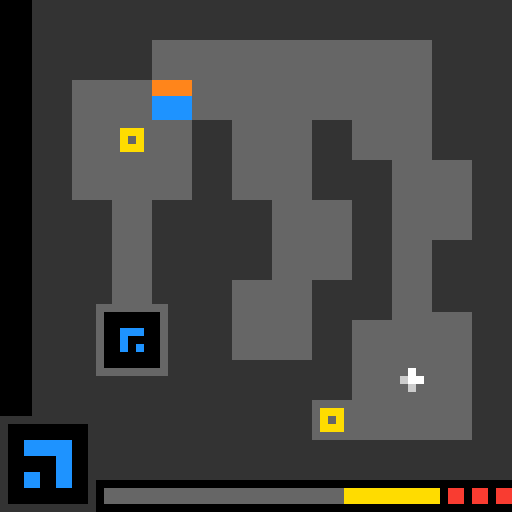

04:31:51 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



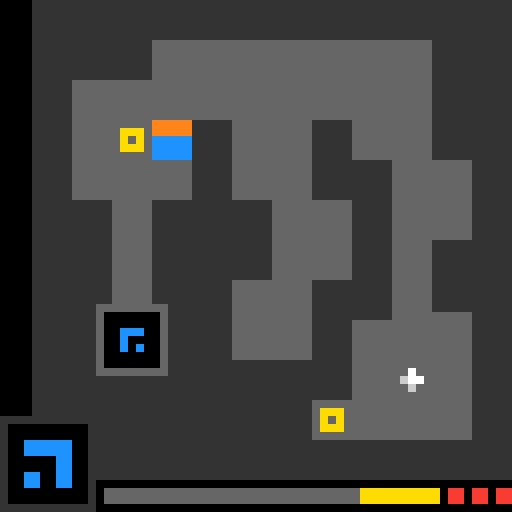

04:31:54 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt | head -n 30'}
  → Floor rows: 5 to 62
Floor cols: 9 to 58
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████




04:32:00 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION3'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



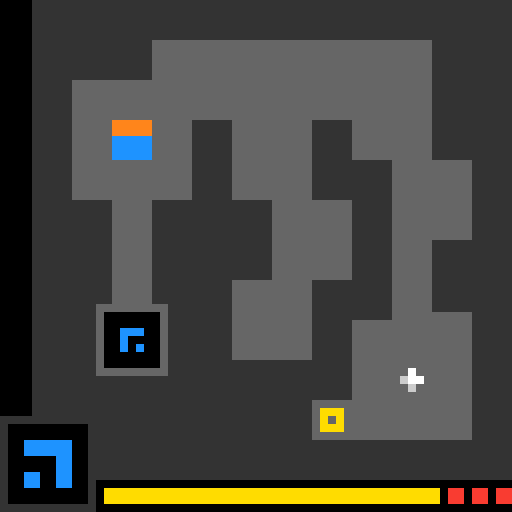

04:32:04 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt | head -n 30'}
  → Floor rows: 5 to 54
Floor cols: 9 to 58
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████
    ████████████████████████████████████████████████████████████




04:32:10 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'cat map.txt | tail -n 25'}
  → ████████.       .████████..........██████████..........█████
    ████████.       .████████..........█████...............█████
    ████████.  bbb  .████████..........█████...............█████
    ████████.  b    .████████..........█████...............█████
    ████████.  b b  .████████..........█████



04:32:30 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION1'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



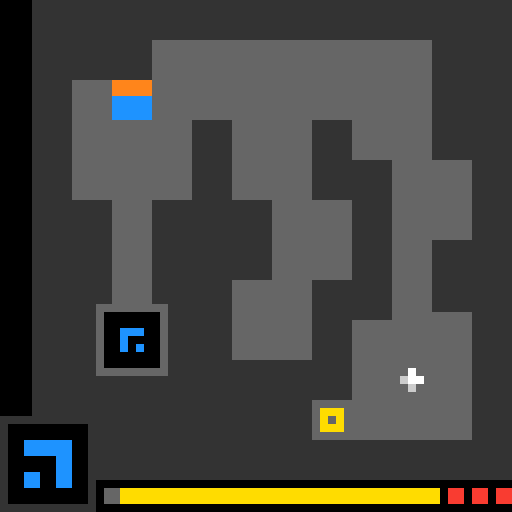

04:32:34 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



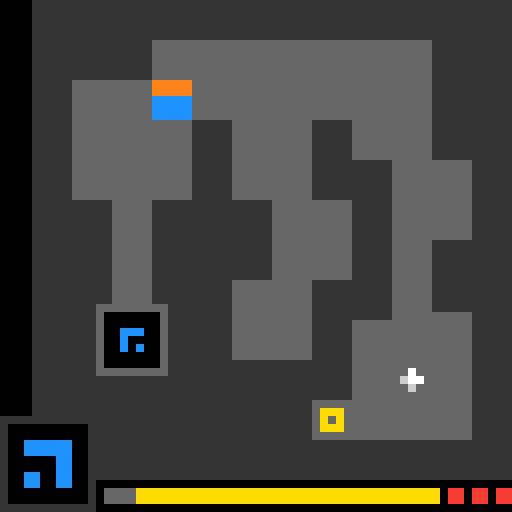

04:32:38 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



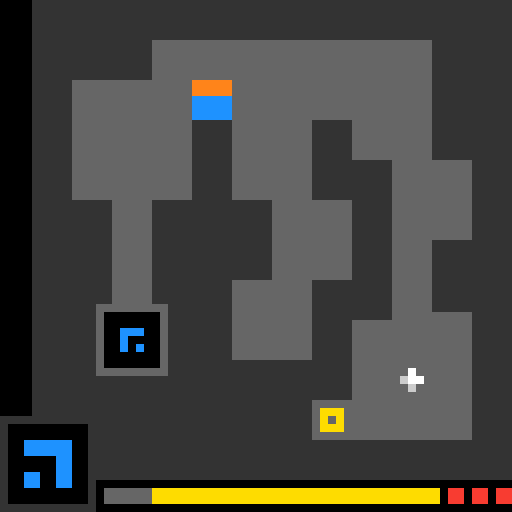

04:32:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



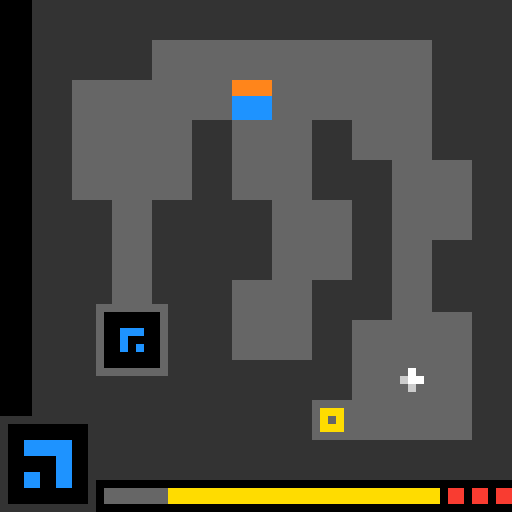

04:32:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



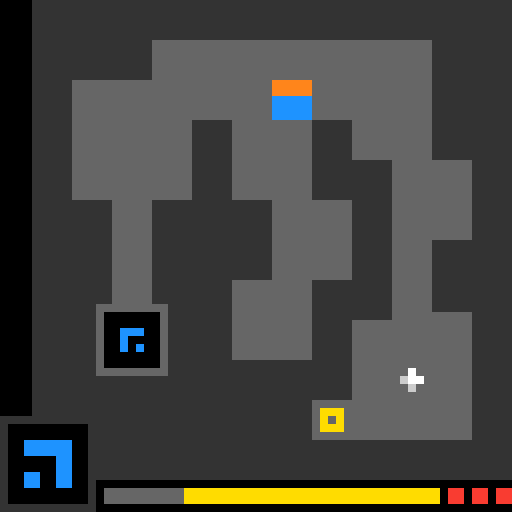

04:32:53 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



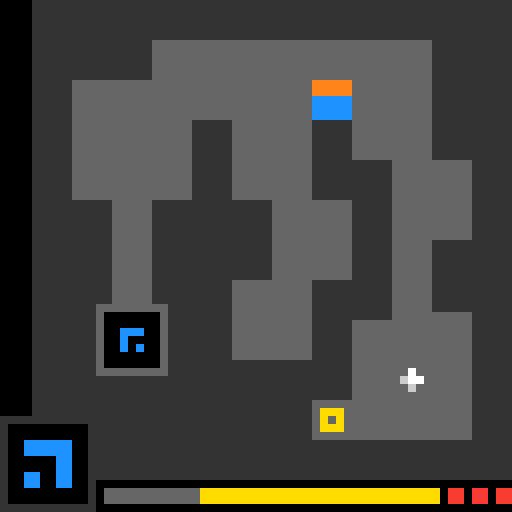

04:32:58 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



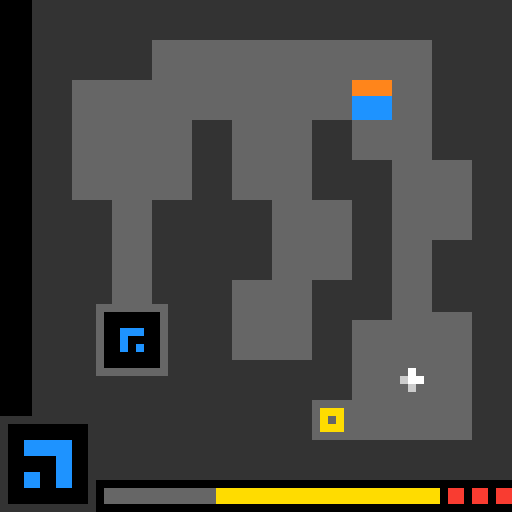

04:33:03 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION4'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



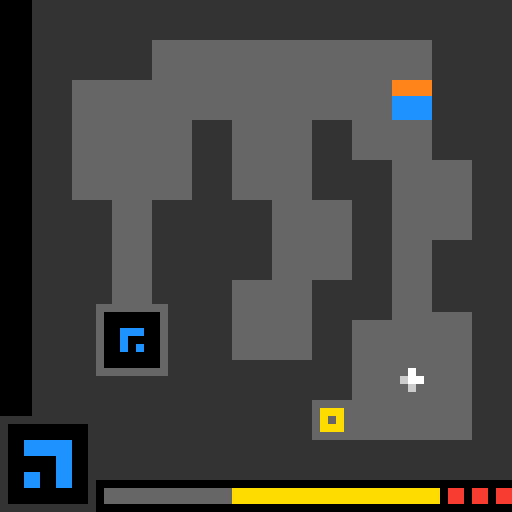

04:33:09 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[bash] {'command': 'python3 find_grid.py && cat map.txt | grep -C 5 CCCCC'}
  → Floor rows: 5 to 62
Floor cols: 9 to 58
    ███████████████...................................██████████
    ███████████████...................................██████████
    ███████████████...................................██████████
    ███████████████...................................██████████




04:33:20 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



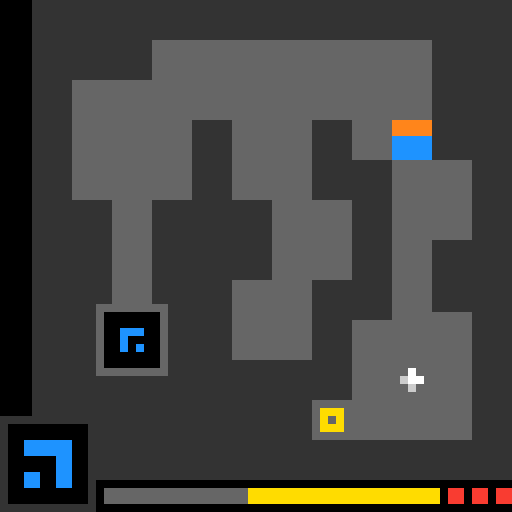

04:33:25 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



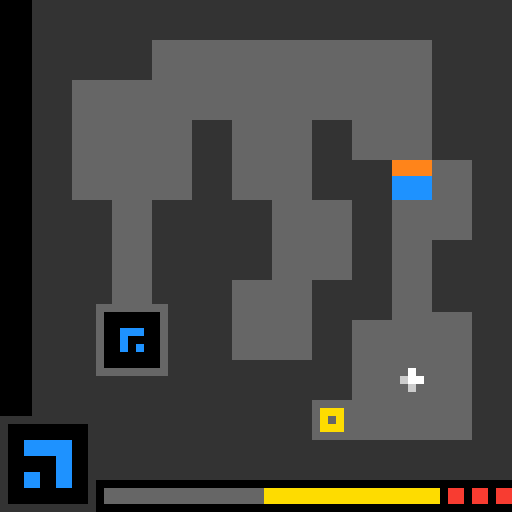

04:33:28 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



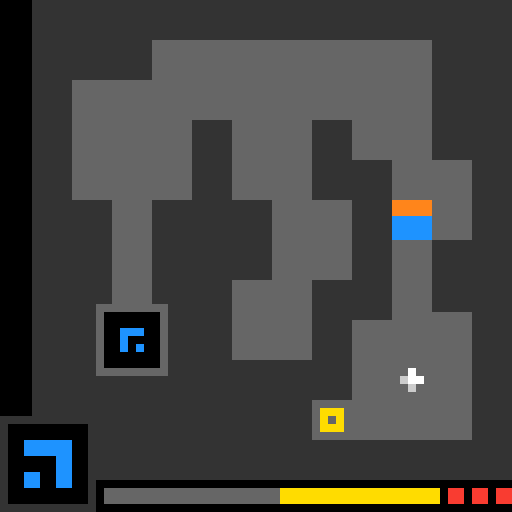

04:33:32 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


[take_action] {'action': 'ACTION2'}
  → state=NOT_FINISHED score=1/7 available=['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.



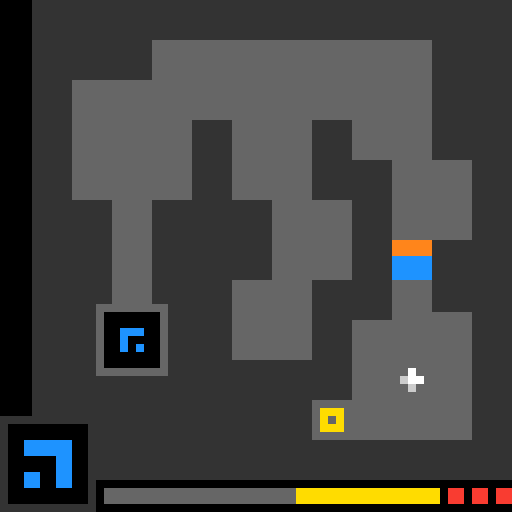

In [3]:
agent.contents = [
    types.Content(role="user", parts=[types.Part(text=(
        f"Game: {arc_session.obs.game_id} | "
        f"Score: {arc_session.obs.levels_completed}/{arc_session.obs.win_levels} | "
        f"Actions: {[GameAction.from_id(a).name for a in arc_session.obs.available_actions]}\n\n"
        f"Current grid is in /home/agent/state.json. "
        f"Full action history is in /home/agent/replay.jsonl.\n\n"
        f"Workflow:\n"
        f"1. Render: python3 -c 'from helpers import *; render_board()' then view_image('board.png')\n"
        f"2. Analyze the grid — find objects, colors, structure, symmetries\n"
        f"3. Take an action, then render + view again to see what changed\n"
        f"4. Write your theory of the rules to notes.md — update it as you learn\n"
        f"5. Use matplotlib to annotate images — draw boxes, arrows, highlights to verify your understanding\n"
        f"6. Never guess randomly. Build a theory, test it, refine it.\n\n"
        f"You can create any visualization you want with matplotlib/pillow and see it with view_image. "
        f"Solve this game."
    ))])
]

agent.contents.append(types.Content(role="user", parts=[
    types.Part(text="solve quickly")]))

for _ in range(100):
    calls = agent.generate_response()
    if not calls:
        last = agent.contents[-1]
        for p in last.parts:
            if hasattr(p, "text") and p.text:
                print(f"[thinking] {p.text[:300]}\n")
    for c in calls:
        print(f"[{c['name']}] {c['args']}")
        print(f"  → {str(c['result'])[:300]}\n")
        if c["name"] == "take_action" and agent.arc_session.obs.frame:
            display(render_frame(agent.arc_session.obs.frame[-1]))
        if c["name"] == "view_image":
            try:
                raw = agent.sbx.read_file(
                    agent.sbx._resolve(c["args"]["file_path"]))
                display(Image.open(io.BytesIO(raw)))
            except:
                pass